# Regression using SciKitLearn
In this tutorial we are going to use an already clean dataset from the [Nomadlist Cities](https://nomadlist.com/) data to predict the continent where the city is located.

We are using [ScikitLearn library](https://scikit-learn.org/stable/index.html)

In [1]:
# Import standard Libraries
import pandas as pd
import seaborn as sns
import altair as alt
import matplotlib.pyplot as plt


sns.set(rc={'figure.figsize':(10,10)})
print("imports ok")

pd.set_option("display.float_format", "{:.3f}".format)

imports ok


In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
# Load data
data = pd.read_csv('/content/gdrive/MyDrive/Machine Learning_Datasets for design/DATASET_nomad.csv')
print(data)

     cost_nomad  cost_coworking  cost_expat  coffee_in_cafe  cost_beer  \
0      1364.000         152.410    1273.000           1.730      1.730   
1       777.000          98.880     780.000           0.850      0.850   
2      1012.000         155.430    1714.000           1.410      1.410   
3      1197.000         131.410    1158.000           2.120      2.120   
4      1352.000         169.560    1347.000           1.410      1.410   
..          ...             ...         ...             ...        ...   
775    3461.000         243.510    2463.000           3.000      3.000   
776    2833.000         288.580    2013.000           2.040      2.040   
777    2525.000         201.550    1148.000           2.480      2.480   
778    1162.000         215.730    1079.000           2.650      2.650   
779    5009.000         360.000    1441.000           5.000      5.000   

     places_to_work  free_wifi_available  internet_speed  freedom_score  \
0             1.000                0

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cost_nomad              780 non-null    float64
 1   cost_coworking          780 non-null    float64
 2   cost_expat              780 non-null    float64
 3   coffee_in_cafe          780 non-null    float64
 4   cost_beer               780 non-null    float64
 5   places_to_work          780 non-null    float64
 6   free_wifi_available     780 non-null    float64
 7   internet_speed          780 non-null    float64
 8   freedom_score           780 non-null    float64
 9   peace_score             780 non-null    float64
 10  safety                  780 non-null    float64
 11  fragile_states_index    780 non-null    float64
 12  press_freedom_index     780 non-null    float64
 13  female_friendly         780 non-null    float64
 14  lgbt_friendly           780 non-null    fl

## Predicting the Nomad Score


Prepare data

In [5]:
# Select the (independant) features that we are going to use to train the model
X = data.loc[:,'cost_nomad':'weed']
X

,cost_nomad,cost_coworking,cost_expat,coffee_in_cafe,cost_beer,places_to_work,free_wifi_available,internet_speed,freedom_score,peace_score,...,fragile_states_index,press_freedom_index,female_friendly,lgbt_friendly,friendly_to_foreigners,racism,leisure,life_score,nightlife,weed
0,1364.000,152.410,1273.000,1.730,1.730,1.000,0.400,31.000,0.600,0.800,...,52.700,28.170,1.000,0.270,0.600,0.400,0.800,0.860,1.000,0.000
1,777.000,98.880,780.000,0.850,0.850,0.800,0.600,14.000,0.200,0.400,...,78.800,44.530,0.800,0.600,0.600,0.400,0.620,0.750,0.400,0.000
2,1012.000,155.430,1714.000,1.410,1.410,0.800,0.400,14.000,0.200,0.400,...,78.800,44.530,0.600,0.800,0.600,0.420,0.600,0.750,0.820,0.000
3,1197.000,131.410,1158.000,2.120,2.120,1.000,1.000,24.000,0.200,0.400,...,78.800,44.530,0.800,0.800,1.000,0.420,0.820,0.720,1.000,0.000
4,1352.000,169.560,1347.000,1.410,1.410,0.800,0.400,15.000,0.200,0.400,...,78.800,44.530,0.800,0.800,1.000,0.400,0.800,0.800,0.800,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
775,3461.000,243.510,2463.000,3.000,3.000,0.200,0.200,2.000,0.600,0.400,...,86.200,25.810,0.200,0.200,0.400,0.000,0.400,0.310,0.200,0.000
776,2833.000,288.580,2013.000,2.040,2.040,0.400,0.200,0.000,0.600,0.200,...,91.000,29.940,0.200,0.200,0.400,0.400,0.200,0.220,0.200,0.000
777,2525.000,201.550,1148.000,2.480,2.480,0.400,0.400,3.000,0.200,0.200,...,96.400,57.890,0.200,0.200,0.800,0.000,0.400,0.220,0.200,0.000
778,1162.000,215.730,1079.000,2.650,2.650,0.400,0.200,2.000,0.200,0.200,...,110.800,81.350,0.200,0.200,0.200,0.000,0.200,0.010,0.200,0.000


In [6]:
# Load and instantiate a StandardSclaer
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

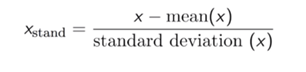

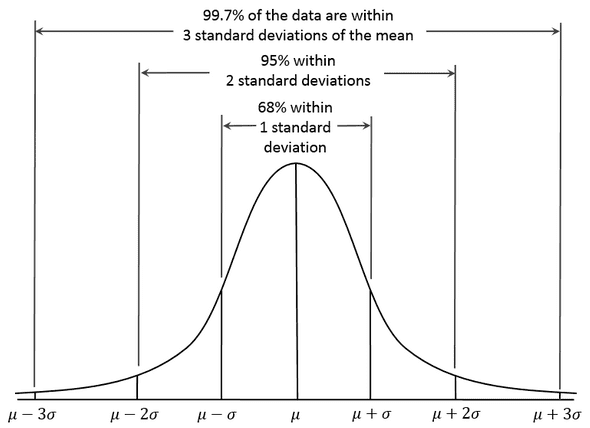

In [8]:
# Apply the scaler to our X-features
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-0.86606693, -0.33259749, -0.48043563, ...,  1.07934063,
         1.68588838, -0.36342189],
       [-1.39139058, -0.64031187, -0.87005443, ...,  0.33496778,
        -0.87811709, -0.36342189],
       [-1.18108213, -0.31523718, -0.13191252, ...,  0.33496778,
         0.91668674, -0.36342189],
       ...,
       [ 0.17294628, -0.0501188 , -0.57922336, ..., -3.25155595,
        -1.73278557, -0.36342189],
       [-1.0468427 ,  0.03139419, -0.63375418, ..., -4.6726314 ,
        -1.73278557, -0.36342189],
       [ 2.3959513 ,  0.86072267, -0.34766492, ..., -3.79291803,
        -0.87811709, -0.36342189]])

In [9]:
print(X_scaled.shape)
tdf = pd.DataFrame(X_scaled)

#print(type(X_scaled))
print(tdf.describe())

(780, 21)
           0       1       2       3       4       5       6       7       8   \
count 780.000 780.000 780.000 780.000 780.000 780.000 780.000 780.000 780.000   
mean   -0.000   0.000  -0.000  -0.000  -0.000  -0.000   0.000  -0.000   0.000   
std     1.001   1.001   1.001   1.001   1.001   1.001   1.001   1.001   1.001   
min    -1.740  -1.209  -1.253  -1.664  -1.664  -2.598  -2.344  -0.748  -1.131   
25%    -0.757  -0.697  -0.688  -0.856  -0.856  -0.780  -0.674  -0.638  -1.131   
50%    -0.110  -0.224  -0.186  -0.119  -0.119  -0.780   0.161  -0.418   0.497   
75%     0.649   0.378   0.418   0.669   0.669   1.038   0.996   0.310   0.497   
max     6.971   7.555   9.108   5.260   5.260   1.946   1.832  10.080   2.124   

           9   ...      11      12      13      14      15      16      17  \
count 780.000  ... 780.000 780.000 780.000 780.000 780.000 780.000 780.000   
mean    0.000  ...   0.000  -0.000   0.000  -0.000   0.000  -0.000  -0.000   
std     1.001  ...   1.001

In [10]:
# Define the dependant variable / target to predict
y_reg = data.nomad_score
print(y_reg)

0     1.000
1     0.950
2     0.850
3     0.840
4     0.840
       ... 
775   0.290
776   0.230
777   0.210
778   0.190
779   0.150
Name: nomad_score, Length: 780, dtype: float64


In [11]:
#Split the data using the train_test_split module. We keep 20% of the data for testing and use 80% to train the model
# Random state defined with an arbitrary number for reproducibility

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, data_train, data_test = train_test_split(X_scaled, y_reg, data, test_size = 0.2, random_state = 42)

In [12]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(624, 21)
(624,)
(156, 21)
(156,)


Train model

In [15]:
# Import and instantiate the baseline model
from sklearn.linear_model import LinearRegression
model = LinearRegression()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is R^2
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.8290112429713021
0.8626880465498491


In [16]:
print("Coefficient", model.coef_, "intercetp",  model.intercept_)

Coefficient [-0.02857005  0.00235348 -0.00053784  0.00303359  0.00303359  0.02015503
 -0.00437667  0.01765882 -0.00934708  0.00480372 -0.00654356  0.01416936
 -0.02509096  0.00105645  0.00089191 -0.00309672  0.00278731  0.00121177
  0.10743123  0.0066859   0.00303627] intercetp 0.6506145526823569


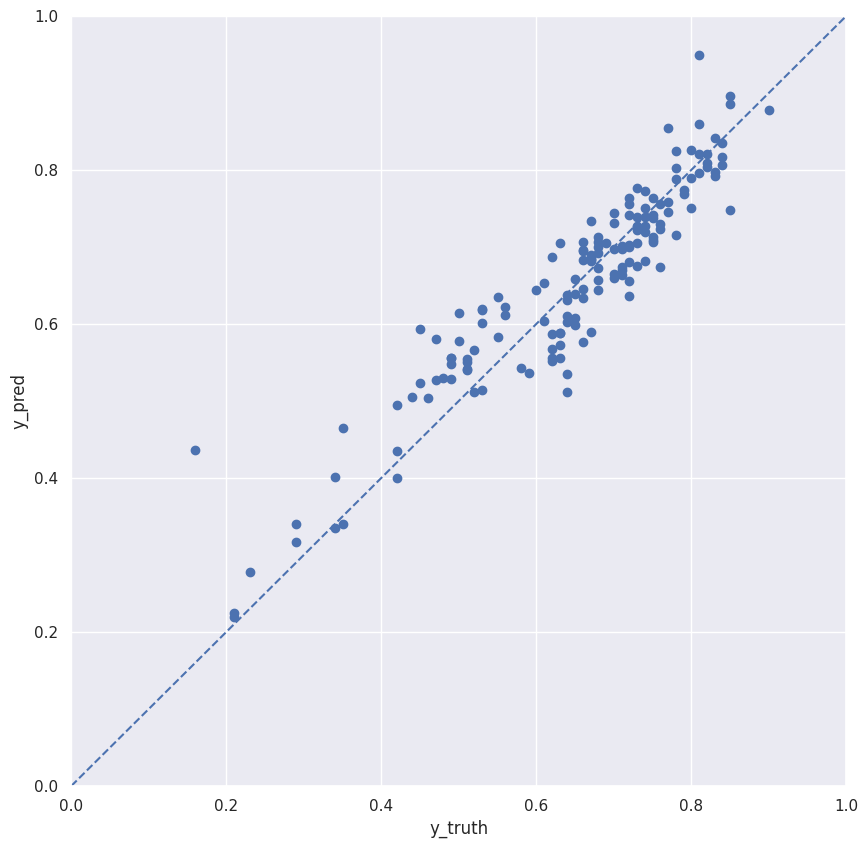

In [17]:
# We can also inspect our results visually
y_pred = model.predict(X_test)

plt.scatter(y_test,y_pred)

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.ylim((0,1))
plt.xlim((0,1))
plt.axline((0,0), slope = 1, ls="--")

In [18]:
data_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156 entries, 595 to 168
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cost_nomad              156 non-null    float64
 1   cost_coworking          156 non-null    float64
 2   cost_expat              156 non-null    float64
 3   coffee_in_cafe          156 non-null    float64
 4   cost_beer               156 non-null    float64
 5   places_to_work          156 non-null    float64
 6   free_wifi_available     156 non-null    float64
 7   internet_speed          156 non-null    float64
 8   freedom_score           156 non-null    float64
 9   peace_score             156 non-null    float64
 10  safety                  156 non-null    float64
 11  fragile_states_index    156 non-null    float64
 12  press_freedom_index     156 non-null    float64
 13  female_friendly         156 non-null    float64
 14  lgbt_friendly           156 non-null    float

In [19]:
data_test['nomadPred_reg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='nomad_score',
    y='nomadPred_reg',
    color=alt.Color('region', scale=alt.Scale(scheme='category10')),
    tooltip=['region', 'place']
).interactive()

alt.Chart(...)

Let's try a different model class

In [20]:
# Import and instantiate a XGBoost Regressor
import xgboost as xgb
model = xgb.XGBRegressor()

# Model training
model.fit(X_train, y_train)

# Model performance on the test-set / This score is not accacy but a R^2
print(model.score(X_test, y_test))

0.9189629309639793


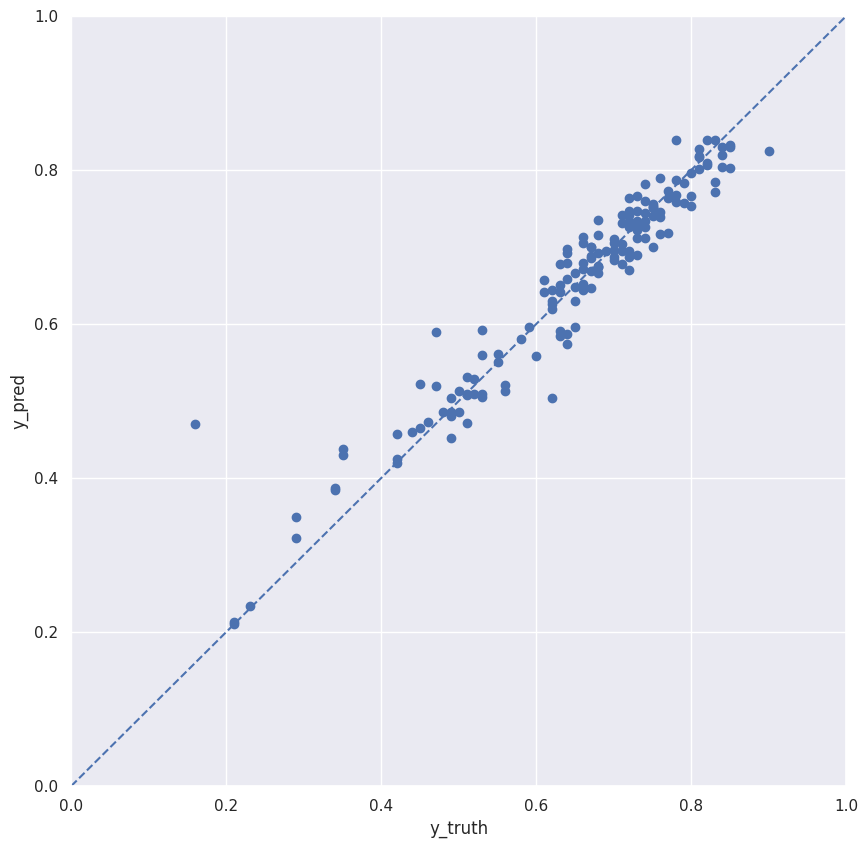

In [21]:
# We can also inspect our results visually
y_pred = model.predict(X_test)

plt.scatter(y_test,y_pred)

plt.xlabel("y_truth")
plt.ylabel("y_pred")
plt.ylim((0,1))
plt.xlim((0,1))
plt.axline((0,0), slope = 1, ls="--")

In [22]:
data_test['nomadPred_xg'] = y_pred

alt.Chart(data_test).mark_circle(size=60).encode(
    x='nomad_score',
    y='nomadPred_xg',
    color=alt.Color('region', scale=alt.Scale(scheme='category10')),
    tooltip=['region','place']
).interactive()

alt.Chart(...)

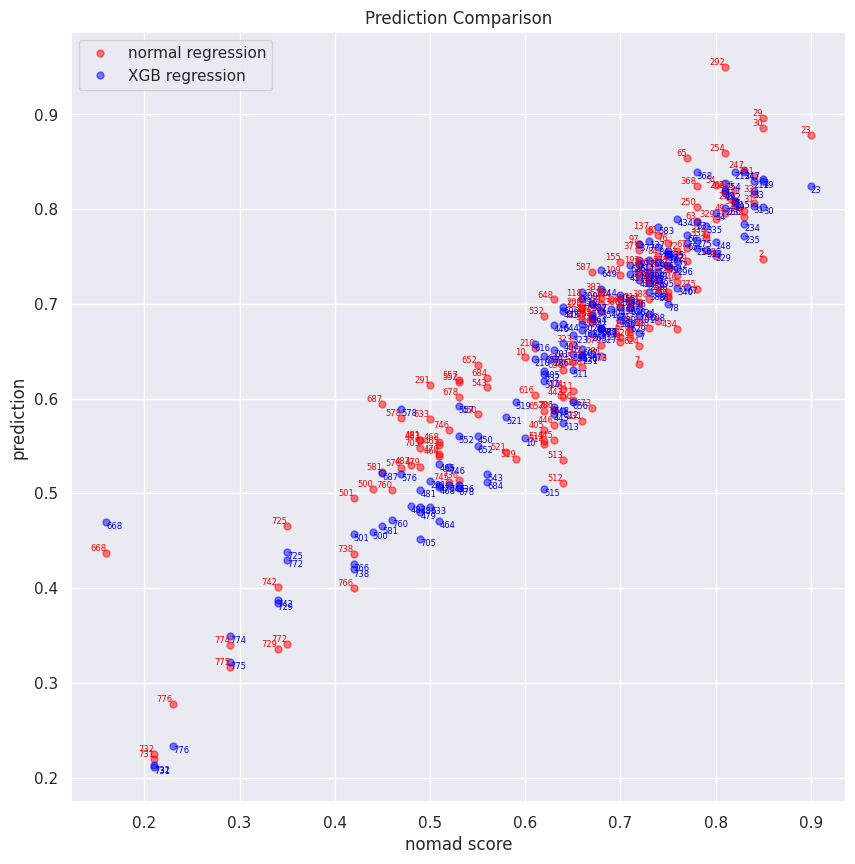

In [23]:
# Comparative plot
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 10))

ax1.plot(
    data_test["nomad_score"],
    data_test["nomadPred_reg"],
    color="red",
    label="normal regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha = 0.5
)

ax1.plot(
    data_test["nomad_score"],
    data_test["nomadPred_xg"],
    color="blue",
    label="XGB regression",
    linestyle='None',
    marker="o",
    markersize=5,
    alpha=0.5
)

# Labels for red points (normal regression)
for idx, (x, y) in data_test[["nomad_score", "nomadPred_reg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='right', va='bottom', color="red")

# Labels for blue points (XGB regression)
for idx, (x, y) in data_test[["nomad_score", "nomadPred_xg"]].iterrows():
    ax1.text(x, y, str(idx), fontsize=6, ha='left', va='top', color="blue")

ax1.set_xlabel('nomad score')
ax1.set_ylabel('prediction')
ax1.legend()

plt.title('Prediction Comparison')
plt.show()